In [1]:
import pandas as pd

# Data
Source: https://cseweb.ucsd.edu/~jmcauley/pdfs/recsys21b.pdf
This is a dataset of users consuming streaming content on Twitch. We retrieved all streamers, and all users connected in their respective chats, every 10 minutes in July 2019 over a 43-day period

In [2]:
twitchdf = pd.read_csv('https://mcauleylab.ucsd.edu/public_datasets/gdrive/twitch/100k_a.csv', header=None, names=["UserID", "StreamID", "Streamer Username", "Time Start", "Time Stop"])
twitchdf.head()

,UserID,StreamID,Streamer Username,Time Start,Time Stop
0,1,33842865744,mithrain,154,156
1,1,33846768288,alptv,166,169
2,1,33886469056,mithrain,587,588
3,1,33887624992,wtcn,589,591
4,1,33890145056,jrokezftw,591,594


<Axes: xlabel='Streamer Username'>

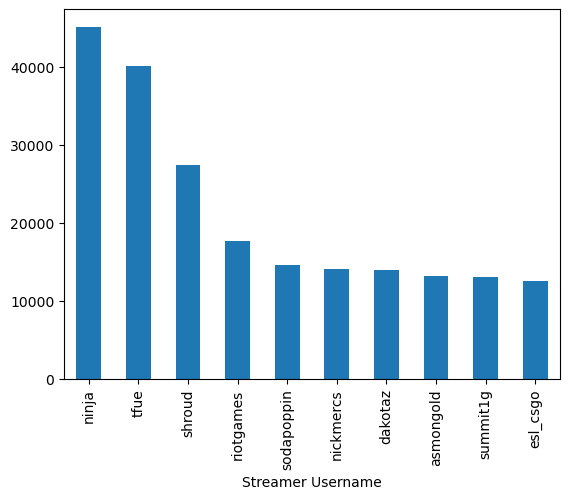

In [3]:
twitchdf["Streamer Username"].value_counts()[:10].plot(kind="bar")

In [4]:
len(twitchdf["Streamer Username"].value_counts())

162625

# 1. Predictive Task
- We will build a recommender system that predicts if you will watch a streamer or not (AKA a Twitch streamer recommender).
- First we will prep the data to just user-streamer interactions, 1 if they interacted, 0 if they did not. We will have to generate a dataset of negatives (a dataset of did not interact) ourselves on a 9:1 ratio. This reflects real world scenarios where most users really only watch a handful of streamers while also still being not too computationally expensive.
- To evaluate the model, we will split the data to 80% for training and 20% for testing. Both splits will maintain a 9:1 ratio. The metric we will use to evaluate the model is Precision@K and Recall@K.
- Our baseline will be recommending globally popular streamers 
- The model we plan to use to improve the baseline is weighted matrix factorization (weighted by % of total time on Twitch spent on watching this streamer)

In [5]:
# For each userID and streamer username pair, add a new column 'proportion of time'

twitchdf['total_watch_time'] = twitchdf['UserID'].map(twitchdf.groupby('UserID').apply(lambda x: (x['Time Stop'] - x['Time Start']).sum()))
twitchdf['watch_time'] = twitchdf['Time Stop'] - twitchdf['Time Start']
twitchdf['proportion_of_time'] = twitchdf['watch_time'] / twitchdf['total_watch_time']

twitchdf.head()

/var/folders/x2/lf91fnjj1qj3wzwkrbxhnslh0000gn/T/ipykernel_72829/2658541231.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  twitchdf['total_watch_time'] = twitchdf['UserID'].map(twitchdf.groupby('UserID').apply(lambda x: (x['Time Stop'] - x['Time Start']).sum()))


,UserID,StreamID,Streamer Username,Time Start,Time Stop,total_watch_time,watch_time,proportion_of_time
0,1,33842865744,mithrain,154,156,117,2,0.017094
1,1,33846768288,alptv,166,169,117,3,0.025641
2,1,33886469056,mithrain,587,588,117,1,0.008547
3,1,33887624992,wtcn,589,591,117,2,0.017094
4,1,33890145056,jrokezftw,591,594,117,3,0.025641


In [7]:
# sum proportion_of_time for each userID and streamer username pair
twitchdf_grouped = twitchdf.groupby(['UserID', 'Streamer Username']).agg({'proportion_of_time': 'sum'}).reset_index()
twitchdf_grouped

,UserID,Streamer Username,proportion_of_time
0,1,alptv,0.025641
1,1,berkriptepe,0.025641
2,1,elraenn,0.017094
3,1,eraymaskulen,0.008547
4,1,esl_csgo,0.008547
...,...,...,...
1505153,100000,mckytv,0.071429
1505154,100000,natehill,0.071429
1505155,100000,ninja,0.214286
1505156,100000,replays,0.071429
